# Circuit Discovery

**Survey Reference:** Section 7.2 - Circuit Discovery Methods

## Overview

**Circuits** are minimal subnetworks that implement specific behaviors. Circuit discovery aims to identify which components (attention heads, MLP neurons, features) are responsible for a particular computation. This is a minimal notebook as this field is large.

### Key Methods

1. **Activation Patching:** Replace activations to measure importance of nodes
2. **Attribution Patching:** Efficient gradient-based approximation for edges

In [61]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, Optional, List, Tuple, Dict
from tqdm import tqdm
from transformer_lens import HookedTransformer, ActivationCache

# Already load the transformer lens model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = HookedTransformer.from_pretrained_no_processing("gpt2").to(device)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  cpu


## 1. Activation Patching

Activation patching is a causal intervention technique used to identify which internal components of a model are responsible for a given behavior.

We compare a **clean input**, where the model predicts correctly, to a **corrupted input**, where a minimal change causes failure. By patching an internal activation from the clean run into the corrupted run, we measure how much that component contributes to correct performance.

$$\text{Effect}(c) = \text{Metric}(\text{model with patch}) - \text{Metric}(\text{corrupted baseline})$$

In this notebook, we apply activation patching to the **Indirect Object Identification (IOI)** task.  
For example:

- **Clean:**  
  *“When Mary and John went to the store, John gave a drink to **Mary**.”*
- **Corrupted:**  
  *“When Mary and John went to the store, Mary gave a drink to **John**.”*

We use the logit difference between the correct and incorrect names at the final token as the evaluation metric.

We first define helpers to create the IOI sentences, define the metric, the list of components to intervene on, and plotting:

In [62]:
def create_ioi_examples():
    """
    Create clean and corrupted IOI examples.
    """
    clean_prompts = [
        "When Mary and John went to the store, John gave a drink to",
        "When Alice and Bob went to the park, Bob gave a flower to",
    ]
    
    corrupted_prompts = [
        "When Mary and John went to the store, Mary gave a drink to",
        "When Alice and Bob went to the park, Alice gave a flower to",
    ]
    
    # Expected answers
    correct_answers = ["Mary", "Alice"]
    incorrect_answers = ["John", "Bob"]
    
    return clean_prompts, corrupted_prompts, correct_answers, incorrect_answers

def tokenize_ioi(
    model,
    clean_prompts,
    corrupted_prompts,
    correct_answers,
    incorrect_answers,
):
    device = model.cfg.device

    clean_tokens = model.tokenizer(
        clean_prompts, return_tensors="pt"
    ).input_ids.to(device)

    corrupted_tokens = model.tokenizer(
        corrupted_prompts, return_tensors="pt"
    ).input_ids.to(device)

    correct_tok = model.tokenizer(
        correct_answers, return_tensors="pt"
    ).input_ids[:, -1].to(device)

    incorrect_tok = model.tokenizer(
        incorrect_answers, return_tensors="pt"
    ).input_ids[:, -1].to(device)

    return clean_tokens, corrupted_tokens, correct_tok, incorrect_tok

def ioi_metric(logits, correct_token_id, incorrect_token_id):
    """
    Standard IOI metric: logit difference at the final position.
    """
    final_logits = logits[:, -1, :]  # (batch, vocab)
    return (
        final_logits[:, correct_token_id]
        - final_logits[:, incorrect_token_id]
    ).mean()

def attention_head_patch_locations(model):
    return [
        (f"blocks.{layer}.attn.hook_z", head)
        for layer in range(model.cfg.n_layers)
        for head in range(model.cfg.n_heads)
    ]

def plot_head_patching_heatmap(effects, n_layers, n_heads):
    """
    Plot a professional heatmap of head-level activation patching effects.
    """

    heatmap = np.full((n_layers, n_heads), np.nan)

    for (hook_name, head), value in effects.items():
        layer = int(hook_name.split(".")[1])
        heatmap[layer, head] = value

    vmax = np.nanmax(np.abs(heatmap))

    plt.figure(figsize=(12, 6))
    im = plt.imshow(
        heatmap,
        aspect="auto",
        vmin=-vmax,
        vmax=vmax,
        interpolation="nearest",
    )

    plt.colorbar(im, label="Δ IOI logit (patched − corrupted)")
    plt.xlabel("Attention head")
    plt.ylabel("Layer")
    plt.xticks(range(n_heads))
    plt.yticks(range(n_layers))
    plt.title("Head-level activation patching effects (IOI)")
    plt.tight_layout()
    plt.show()

Activation patching simply replaces the component's output in the corrupted prompt with the component's activation in the clean prompt:

In [63]:
def activation_patching(
    model,
    clean_prompts,
    corrupted_prompts,
    correct_answers,
    incorrect_answers,
    metric_fn: Callable,
    patch_locations: list[str],
):
    """
    Perform activation patching to identify important components.
    """

    clean_tokens, corrupted_tokens, correct_tok, incorrect_tok = tokenize_ioi(
        model,
        clean_prompts,
        corrupted_prompts,
        correct_answers,
        incorrect_answers,
    )
    
    effects = {}

    _, clean_cache = model.run_with_cache(clean_tokens)
    corrupted_logits, _ = model.run_with_cache(corrupted_tokens)

    corrupted_metric = metric_fn(
        corrupted_logits,
        correct_tok,
        incorrect_tok,
    )

    for loc, head in patch_locations:

        def patch_hook(activation, hook, head=head):
            # activation: (batch, seq, n_heads, d_head)
            activation[:, :, head, :] = clean_cache[hook.name][:, :, head, :]
            return activation

        patched_logits = model.run_with_hooks(
            corrupted_tokens,
            fwd_hooks=[(loc, patch_hook)],
        )

        patched_metric = metric_fn(
            patched_logits,
            correct_tok,
            incorrect_tok,
        )

        effects[(loc, head)] = (patched_metric - corrupted_metric).item()
    return effects

Running activation patching

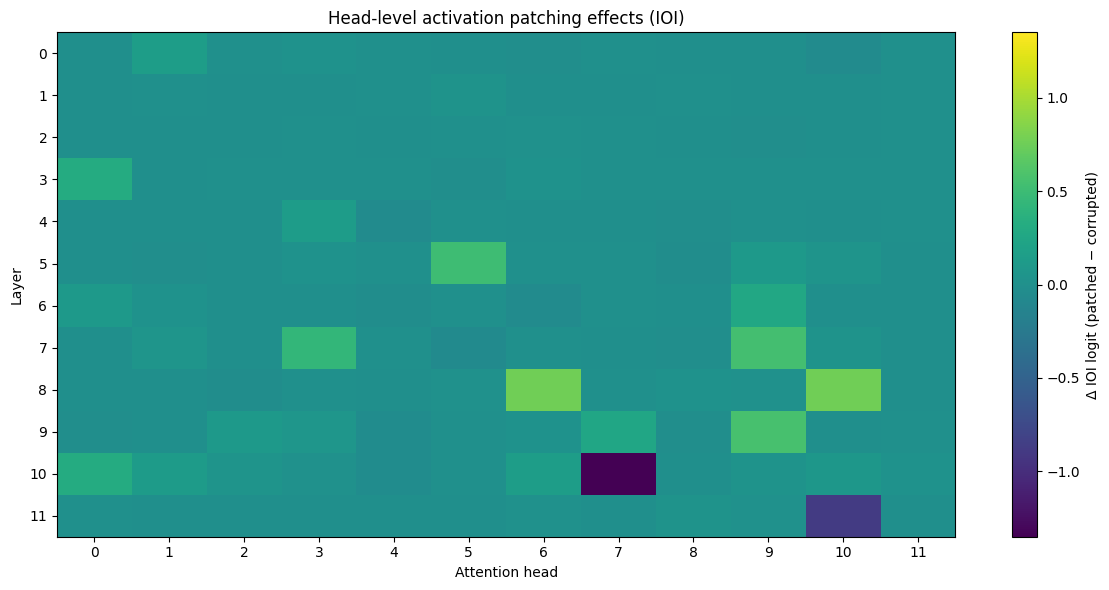

In [64]:
clean_prompts, corrupted_prompts, correct_answers, incorrect_answers = create_ioi_examples()
metric_fn = ioi_metric
patch_locations = attention_head_patch_locations(model)

effects = activation_patching(
    model=model,
    clean_prompts=clean_prompts,
    corrupted_prompts=corrupted_prompts,
    correct_answers=correct_answers,
    incorrect_answers=incorrect_answers,
    metric_fn=metric_fn,
    patch_locations=patch_locations,
)

plot_head_patching_heatmap(
    effects,
    n_layers=model.cfg.n_layers,   # GPT-2 small
    n_heads=model.cfg.n_heads,
)

## 2. Attribution Patching (Gradient-Based)

Activation patching measures the effect of *directly replacing* one component.  
Attribution patching instead asks: **how does one component influence another downstream component?**

For example: *how does an MLP in layer 2 affect an attention head in layer 10?*

Because transformers update the residual stream additively, the influence of one component on another could in principle be measured by explicitly subtracting the source component’s contribution from the **input of the target component** and measuring the change in the final metric. However, this would require \(O(n^2)\) forward passes for \(n\) components, which quickly becomes infeasible for large models.

Attribution patching avoids this cost by using gradients. We consider a **clean run**, and a **corrupted run** in which the **source component’s contribution has been removed from the target component’s input**. We then approximate the effect of a source component \(c\) on the metric by linearizing the metric around the target input activation \(a\):

$$
\text{AttrPatch}(c)
\approx
\nabla_{a}\,\text{Metric}
\;\cdot\;
\bigl(a^{\text{clean}} - a^{\text{corrupted}}\bigr)
$$

where \(a\) denotes the activation at the **input of the target component**.

This requires only **two forward passes** (clean and corrupted) and **one backward pass**.


We first collect the activations for the clean and the corrupted prompts:

In [65]:
def collect_clean_fwd_bwd(
    model,
    tokens,
    metric_fn,
    correct_tok,
    incorrect_tok,
):
    fwd, bwd = {}, {}

    def wrapped_metric(logits):
        return metric_fn(logits, correct_tok, incorrect_tok)

    def fwd_hook(act, hook):
        fwd[hook.name] = act.detach()

    def bwd_hook(grad, hook):
        bwd[hook.name] = grad.detach()

    model.reset_hooks()

    model.add_hook(lambda n: "attn.hook_z" in n, fwd_hook, "fwd")

    for tag in ("hook_q_input", "hook_k_input", "hook_v_input"):
        model.add_hook(lambda n, tag=tag: tag in n, bwd_hook, "bwd")

    model.zero_grad(set_to_none=True)
    wrapped_metric(model(tokens)).backward()
    model.reset_hooks()

    return (
        ActivationCache(fwd, model),
        ActivationCache(bwd, model),
    )

def collect_corrupted_fwd(
    model,
    tokens,
):
    fwd = {}

    def fwd_hook(act, hook):
        fwd[hook.name] = act.detach()

    model.reset_hooks()
    model.add_hook(lambda n: "attn.hook_z" in n, fwd_hook, "fwd")
    _ = model(tokens)
    model.reset_hooks()

    return ActivationCache(fwd, model)

Since we focus on attention heads, we need to multiply the hook z attention ouput at the source with its W_O matrix to localize the contribution of this specific head:

In [66]:
def layer_head_list(model):
    return [
        (layer, head)
        for layer in range(model.cfg.n_layers)
        for head in range(model.cfg.n_heads)
    ]
def project_WO(model, layer: int, head: int, z: torch.Tensor) -> torch.Tensor:
    W_O = model.blocks[layer].attn.W_O.to(z.device)
    return z @ W_O[head]  # [d_head] → [d_model]

def compute_source_deltas(
    model,
    fwd_clean: ActivationCache,
    fwd_corrupt: ActivationCache,
    heads: List[Tuple[int, int]],
):
    deltas = {}

    for layer, head in heads:
        z_clean = fwd_clean[f"blocks.{layer}.attn.hook_z"][0, -1, head]
        z_corr  = fwd_corrupt[f"blocks.{layer}.attn.hook_z"][0, -1, head]

        # replace the corrupted contribution with the clean contribution
        deltas[(layer, head)] = (
            project_WO(model, layer, head, z_clean)
            - project_WO(model, layer, head, z_corr)
        )

    return deltas

def compute_head_to_head_effects(
    source_deltas: Dict[Tuple[int, int], torch.Tensor],
    bwd_clean: ActivationCache,
    heads: List[Tuple[int, int]],
):
    effects = {}

    for srcL, srcH in heads:
        delta = source_deltas[(srcL, srcH)]

        for tgtL, tgtH in heads:
            if tgtL <= srcL:
                continue

            total = 0.0
            for comp in ("q", "k", "v"):
                key = f"blocks.{tgtL}.hook_{comp}_input"
                if key not in bwd_clean:
                    continue

                grad = bwd_clean[key][0, -1, tgtH]
                total += grad @ delta

            effects[(srcL, srcH, tgtL, tgtH)] = float(total.item())

    return effects

In [67]:
def attribution_patching_head_to_head(
    model,
    clean_prompts,
    corrupted_prompts,
    correct_answers,
    incorrect_answers,
    metric_fn,
):
    model.set_use_attn_result(True)
    model.set_use_split_qkv_input(True)

    heads = layer_head_list(model)

    clean_tokens, corrupted_tokens, correct_tok, incorrect_tok = tokenize_ioi(
        model,
        clean_prompts,
        corrupted_prompts,
        correct_answers,
        incorrect_answers,
    )

    fwd_clean, bwd_clean = collect_clean_fwd_bwd(
        model,
        clean_tokens,
        metric_fn,
        correct_tok,
        incorrect_tok,
    )

    fwd_corrupt = collect_corrupted_fwd(
        model,
        corrupted_tokens,
    )

    source_deltas = compute_source_deltas(
        model,
        fwd_clean,
        fwd_corrupt,
        heads,
    )

    return compute_head_to_head_effects(
        source_deltas,
        bwd_clean,
        heads,
    )


We run attribution patching:

In [68]:
effects = attribution_patching_head_to_head(
    model=model,
    clean_prompts=clean_prompts,
    corrupted_prompts=corrupted_prompts,
    correct_answers=correct_answers,
    incorrect_answers=incorrect_answers,
    metric_fn=metric_fn
)

Finally, we print the top10 most importants edges between attention edges: 

In [69]:
def print_top_k_edges(effects, k=10, abs_sort=True):
    """
    Pretty-print the top-k most important head → head edges.

    effects: dict[(srcL, srcH, tgtL, tgtH)] -> float
    """

    # Sort edges
    items = list(effects.items())
    if abs_sort:
        items.sort(key=lambda x: abs(x[1]), reverse=True)
    else:
        items.sort(key=lambda x: x[1], reverse=True)

    print(f"Top {k} attention head → head edges:\n")
    print(f"{'Rank':<5} {'Source':<12} {'Target':<12} {'Score':>10}")
    print("-" * 45)

    for i, ((srcL, srcH, tgtL, tgtH), score) in enumerate(items[:k], start=1):
        src = f"L{srcL}H{srcH}"
        tgt = f"L{tgtL}H{tgtH}"
        print(f"{i:<5} {src:<12} {tgt:<12} {score:>10.4f}")

print_top_k_edges(effects, k=10)

Top 10 attention head → head edges:

Rank  Source       Target            Score
---------------------------------------------
1     L9H9         L11H10          -0.4150
2     L10H7        L11H10           0.4068
3     L9H9         L10H7           -0.1561
4     L8H10        L11H10          -0.1288
5     L9H6         L10H7           -0.1237
6     L8H10        L9H9             0.1206
7     L8H10        L10H0            0.1160
8     L9H6         L11H10          -0.1098
9     L10H7        L11H1           -0.0964
10    L7H3         L8H10           -0.0963
